In [1]:
import numpy as np
import cv2
# from google.colab.patches import cv2_imshow
import math
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
Path.cwd()

WindowsPath('c:/Users/jsrojas/Documents/Código/Exccess_fractions/notebooks')

Imagen cargada exitosamente desde: c:\Users\jsrojas\Documents\Código\Exccess_fractions\data\01_raw\block_2.5_mm(simulated).png
Dimensiones de la imagen: (2400, 2400)


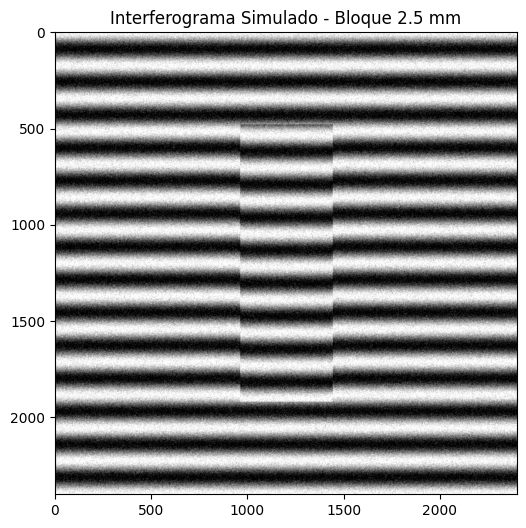

In [3]:
# En VS Code Jupyter, Path.cwd() apunta a la carpeta donde está este notebook (ej. 'notebooks/')
notebook_path = Path.cwd()

# Subimos un nivel a la raíz del proyecto para luego entrar a 'data/01_raw'
root_path = notebook_path.parent
images_path = root_path / "data" / "01_raw"

file_name = "block_2.5_mm(simulated).png"
complete_path = images_path / file_name

if complete_path.exists():
    # Mantenemos la lectura con numpy para evitar el conflicto de tildes en Windows
    img_array = np.fromfile(complete_path, np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        print(f"Imagen cargada exitosamente desde: {complete_path}")
        print(f"Dimensiones de la imagen: {img.shape}")
        
        # RECOMENDACIÓN: Mostrar la imagen embebida en el notebook con matplotlib
        # Esto evita ventanas externas flotantes que congelan VS Code
        plt.figure(figsize=(8, 6))
        plt.imshow(img, cmap='gray')
        plt.title("Interferograma Simulado - Bloque 2.5 mm")
        plt.axis('on')  # Muestra las coordenadas en píxeles, útil para ubicar las franjas
        plt.show()
        
    else:
        print("Error: El archivo fue encontrado, pero OpenCV no pudo decodificarlo como imagen.")
else:
    print(f"Error: Archivo no encontrado en la ruta: {complete_path}")

In [4]:
# Definir coordenadas (y1:y2, x1:x2) - Esto dependerá de tu imagen
roi_platina = img[700:1900, 500:900]  # Tira superior (referencia)
roi_bloque  = img[700:1900, 1000:1400] # Tira central (bloque)

# Promediar las columnas (eje Y) para reducir el ruido
# Esto colapsa el ROI en un arreglo 1D (el perfil de intensidad)
perfil_platina = np.mean(roi_platina, axis=1)
perfil_bloque  = np.mean(roi_bloque, axis=1)

# El eje X son los índices de los píxeles
x = np.arange(len(perfil_platina))

In [5]:
perfil_bloque.shape

(1200,)

In [6]:
perfil_platina.shape

(1200,)

In [7]:
img.shape

(2400, 2400)

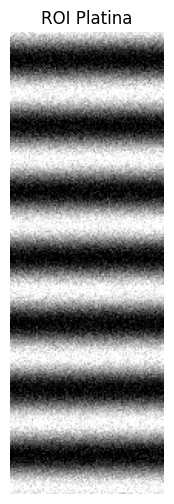

In [8]:
plt.figure(figsize=(6,6))
plt.imshow(roi_platina, cmap='gray')
plt.title("ROI Platina")
plt.axis('off')
plt.show()

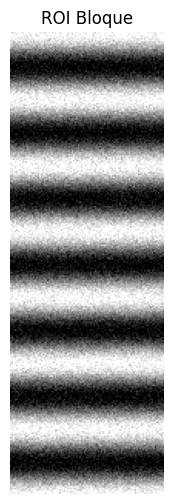

In [9]:
plt.figure(figsize=(6,6))
plt.imshow(roi_bloque, cmap='gray')
plt.title("ROI Bloque")
plt.axis('off')
plt.show()

In [10]:
# función de ajuste
def interference_model(x, A, w, phi, C):
    return A * np.sin(w * x + phi) + C

def evaluate_fit(x, data_profile, fit_params, pcov, name="Data"):

  # Calculate theoretical curve
  y_theoretical = interference_model(x, *fit_params)

  # Calculate residuals and RMSE
  residuals = data_profile - y_theoretical
  rmse = np.sqrt(np.mean(residuals**2))

  # Calculate R^2 safely to prevent divide-by-zero
  ss_res = np.sum(residuals**2)
  ss_tot = np.sum((data_profile - np.mean(data_profile))**2)

  # Check if the data is a flat line
  if ss_tot == 0:
      print(f"WARNING: The raw data for {name} is a perfectly flat line (variance is 0).")
      r2 = float('-inf')
  else:
      r2 = 1 - (ss_res / ss_tot)

  # Calculate Phase uncertainty safely
  if np.isinf(pcov).any():
      phi_error = float('inf')
  else:
      phi_error = np.sqrt(np.diag(pcov))[2] # Index 2 corresponds to 'phase'

  # --- Print Report ---
  print(f"--- QUALITY REPORT: {name} ---")
  print(f"R^2                 : {r2:.4f} (Ideal > 0.85)")
  print(f"RMSE                : {rmse:.2f} intensity units")
  print(f"Phase Uncertainty   : +/- {phi_error:.4f} radians")
  print("-" * 40)

  # --- Diagnostic Plot ---
  # This plot will reveal what the algorithm is actually trying to fit
  plt.figure(figsize=(8, 4))
  plt.plot(x, data_profile, '.', label=f'Raw Data ({name})', color='gray')
  plt.plot(x, y_theoretical, '-', label='Fitted Curve', color='red', linewidth=2)
  plt.title(f"Diagnostic Plot - {name}")
  plt.xlabel("Pixels (X-axis)")
  plt.ylabel("Intensity (Y-axis)")
  plt.legend()
  plt.grid(True)
  plt.show()

In [11]:
# Estimaciones iniciales
# A: (max - min) / 2
# C: promedio
# w: estimar contando picos o adivinar frecuencia baja (ej. 2*pi / 50 píxeles)
guess_A = (np.max(perfil_platina) - np.min(perfil_platina)) / 2
guess_C = np.mean(perfil_platina)
pixels_among_fringes = 175.0
guess_w = 2 * np.pi / pixels_among_fringes
guess_phi = 0.0

--- QUALITY REPORT: Platina ---
R^2                 : 0.9973 (Ideal > 0.85)
RMSE                : 4.58 intensity units
Phase Uncertainty   : +/- 0.0030 radians
----------------------------------------


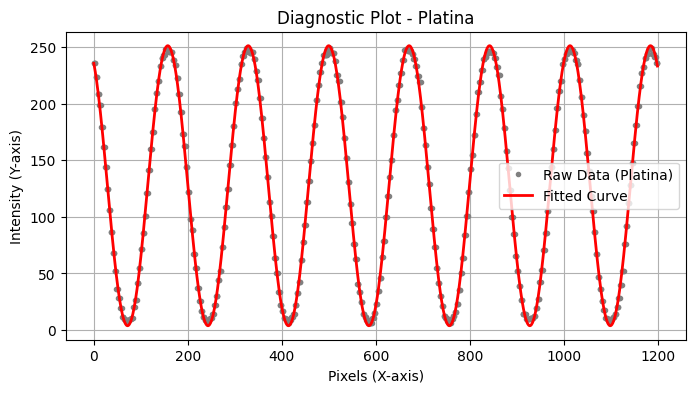

In [12]:
p0 = [guess_A, guess_w, guess_phi, guess_C]

# Limites inferiores: [Amplitud > 0, Frecuencia > 0, Fase -pi, Brillo > 0]
# Limites superiores: [Amplitud máxima, Frecuencia alta, Fase +pi, Brillo máximo]
limites = (
    [0, guess_w * 0.5, -np.pi, 0],
    [np.inf, guess_w * 1.5, np.pi, 255]
)

# Ajusta el perfil de la platina (Referencia)
params_platina, covarianza_platina = curve_fit(
    interference_model,
    x,
    perfil_platina,
    p0=p0,
    # bounds=limites,
    maxfev=5000 # Darle más intentos para resolverlo
)
A_ref, w_ref, phi_ref, C_ref = params_platina

# Check fitting
evaluate_fit(x, data_profile=perfil_platina, fit_params=params_platina, pcov=covarianza_platina, name="Platina")

--- QUALITY REPORT: Bloque ---
R^2                 : 0.9973 (Ideal > 0.85)
RMSE                : 4.54 intensity units
Phase Uncertainty   : +/- 0.0030 radians
----------------------------------------


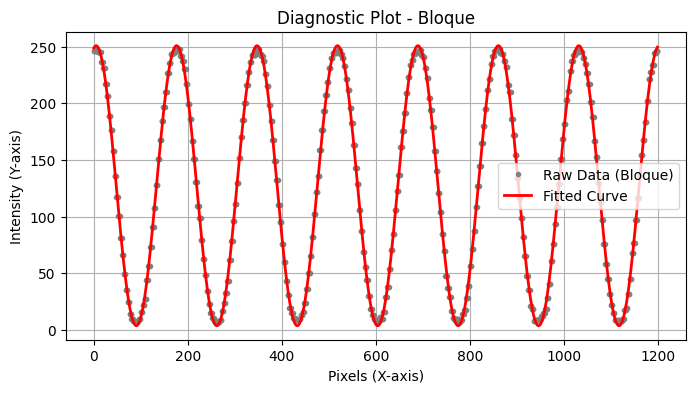

In [13]:
# Ajusta el perfil del bloque
# Se usa la misma 'w' de la platina como estimación inicial porque el espaciado b es el mismo
p0_bloque = [guess_A, w_ref, guess_phi, guess_C]
limites_bloque = (
    [0, w_ref * 0.99, -np.pi, 0],
    [np.inf, w_ref * 1.01, np.pi, 255]
)

params_bloque, covarianza_bloque = curve_fit(
    interference_model,
    x,
    perfil_bloque,
    p0=p0_bloque,
    # bounds=limites_bloque,
    maxfev=5000
)
A_blk, w_blk, phi_blk, C_blk = params_bloque

# Check fitting
evaluate_fit(x, data_profile=perfil_bloque, fit_params=params_bloque, pcov=covarianza_bloque, name="Bloque")

In [14]:
# Calcula la fracción a/b
# Asegurar que las fases estén en el rango [0, 2pi)
phi_ref = phi_ref % (2 * np.pi)
phi_blk = phi_blk % (2 * np.pi)

diferencia_fase = phi_blk - phi_ref

# Si la diferencia es negativa, dependiendo de la dirección de la cuña, se ajusta
if diferencia_fase < 0:
    diferencia_fase += 2 * np.pi

fraccion_observada = diferencia_fase / (2 * np.pi)

print(f"Fase Platina: {phi_ref:.3f} rad")
print(f"Fase Bloque:  {phi_blk:.3f} rad")
print(f"Fracción de Franja (f = a/b): {fraccion_observada:.4f}")

Fase Platina: 5.220 rad
Fase Bloque:  1.392 rad
Fracción de Franja (f = a/b): 0.3908


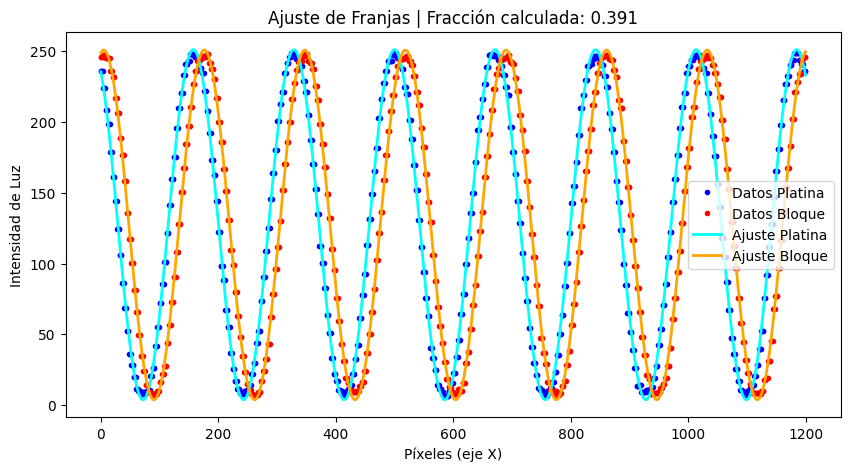

In [15]:
plt.figure(figsize=(10, 5))
# Plotear datos crudos
plt.plot(x, perfil_platina, '.', label="Datos Platina", color='blue')
plt.plot(x, perfil_bloque, '.', label="Datos Bloque", color='red')

# # Plotear el ajuste ideal
plt.plot(x, interference_model(x, *params_platina), '-', label="Ajuste Platina", color='cyan', linewidth=2)
plt.plot(x, interference_model(x, *params_bloque), '-', label="Ajuste Bloque", color='orange', linewidth=2)

plt.title(f"Ajuste de Franjas | Fracción calculada: {fraccion_observada:.3f}")
plt.xlabel("Píxeles (eje X)")
plt.ylabel("Intensidad de Luz")
plt.legend()
plt.show()